# 01 — Kerr–Schild Geometry

This notebook constructs the Kerr spacetime in Cartesian Kerr–Schild coordinates and verifies the core identities we will rely on later.

We use geometrized units, $G=c=1$, and metric signature

$$\eta_{\mu\nu}=\mathrm{diag}(-1,1,1,1).$$

The Kerr–Schild metric is written as

$$g_{\mu\nu}=\eta_{\mu\nu}+2H\,\ell_\mu\ell_\nu.$$

The main goal of this notebook is **not** to expand giant symbolic expressions. Instead, we keep the geometry factored and verify identities that can later be turned into a fast numerical geodesic kernel.


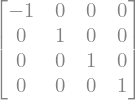

In [1]:
import sympy as sp
from sympy import Matrix

sp.init_printing()

# Coordinates and physical parameters
t, x, y, z = sp.symbols('t x y z', real=True)
M = sp.symbols('M', positive=True, real=True)
a = sp.symbols('a', real=True)

coords = (t, x, y, z)

eta = sp.diag(-1, 1, 1, 1)
eta_inv = eta  # its own inverse for this signature

eta


## 1. Kerr radial coordinate $r(x,y,z)$

In Cartesian Kerr–Schild coordinates, the Kerr radial coordinate is **not** the Euclidean radius $\sqrt{x^2+y^2+z^2}$ when $a\neq 0$.

It obeys

$$r^4-\left(x^2+y^2+z^2-a^2\right)r^2-a^2z^2=0.$$

Choosing the physical non-negative branch gives

$$r^2=\frac{1}{2}\left[\rho^2-a^2+\sqrt{\left(\rho^2-a^2\right)^2+4a^2z^2}\right],$$

where $\rho^2=x^2+y^2+z^2$.


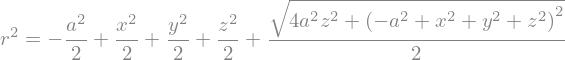

In [2]:
rho2 = x**2 + y**2 + z**2
A = rho2 - a**2
disc = sp.sqrt(A**2 + 4*a**2*z**2)

r2 = sp.Rational(1, 2) * (A + disc)
r = sp.sqrt(r2)

sp.Eq(sp.Symbol('r^2'), r2)


### Check the defining quartic relation

We verify the expression for $r^2$ before using it anywhere else.


In [3]:
quartic_check = sp.simplify(r2**2 - A*r2 - a**2*z**2)
quartic_check


The result should be exactly `0`.


## 2. Kerr–Schild null one-form $\ell_\mu$

For one standard ingoing Kerr–Schild convention,

$$\ell_\mu=\left(
1,
\frac{rx+ay}{r^2+a^2},
\frac{ry-ax}{r^2+a^2},
\frac{z}{r}
\right).$$

Different references may use overall or spin-sign changes depending on coordinate convention. We will keep this convention fixed throughout the project.


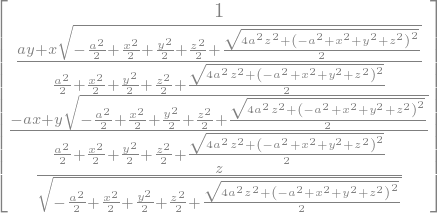

In [4]:
ell_cov = Matrix([
    1,
    (r*x + a*y) / (r2 + a**2),
    (r*y - a*x) / (r2 + a**2),
    z / r,
])

ell_cov


Raise the index using the flat Minkowski background:

$$\ell^\mu=\eta^{\mu\nu}\ell_\nu.$$


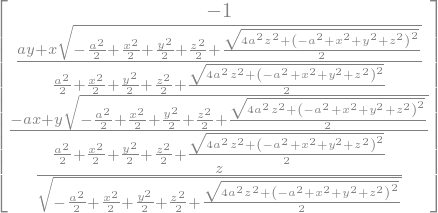

In [5]:
ell_contra = eta_inv * ell_cov
ell_contra


### Verify that $\ell^\mu$ is null

The Kerr–Schild construction requires

$$\eta_{\mu\nu}\ell^\mu\ell^\nu=0.$$

Rather than asking SymPy to globally simplify a huge expression, we reduce the numerator after combining terms.


In [6]:
null_expr = (ell_contra.T * eta * ell_contra)[0]

# Use together/cancel rather than indiscriminate simplify.
null_reduced = sp.cancel(sp.together(null_expr))
null_reduced


If SymPy does not immediately print `0` because of nested radicals, we can verify the identity numerically and also analytically using the defining relation for $r$.


In [7]:
# Numerical spot check away from coordinate singularities
null_num = sp.lambdify((x, y, z, a), null_expr, modules='numpy', cse=True, docstring_limit=0)

test_value = null_num(7.0, 2.0, 1.5, 0.6)
print('null check =', test_value)


null check = 2.220446049250313e-16


## 3. Kerr–Schild scalar $H$

For Kerr,

$$H=\frac{Mr^3}{r^4+a^2z^2}.$$

We keep this factored rather than expanding it.


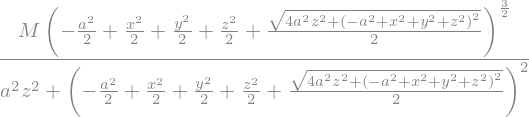

In [8]:
H = M * r**3 / (r**4 + a**2*z**2)
H


## 4. Construct $g_{\mu\nu}$

$$g_{\mu\nu}=\eta_{\mu\nu}+2H\ell_\mu\ell_\nu.$$


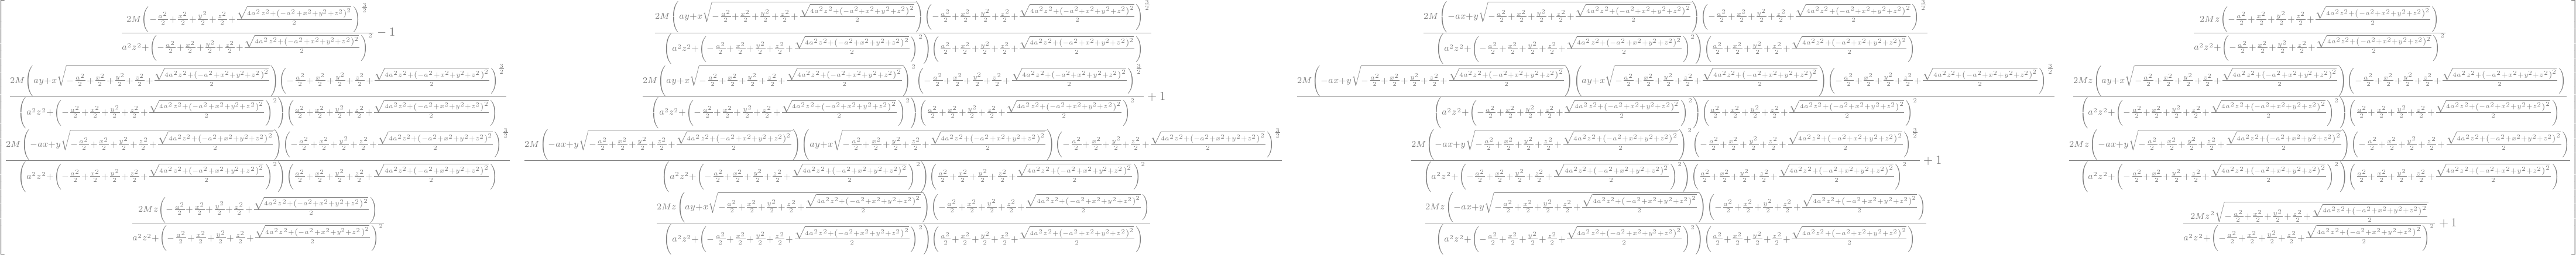

In [9]:
g_cov = eta + 2*H*(ell_cov * ell_cov.T)

# Keep the matrix factored. Avoid g_cov.applyfunc(sp.simplify).
g_cov


## 5. Use the analytic Kerr–Schild inverse

Because $\ell^\mu$ is null, we do **not** need to call `Matrix.inv()` on the symbolic Kerr metric.

$$g^{\mu\nu}=\eta^{\mu\nu}-2H\ell^\mu\ell^\nu.$$

This is both mathematically cleaner and computationally much cheaper.


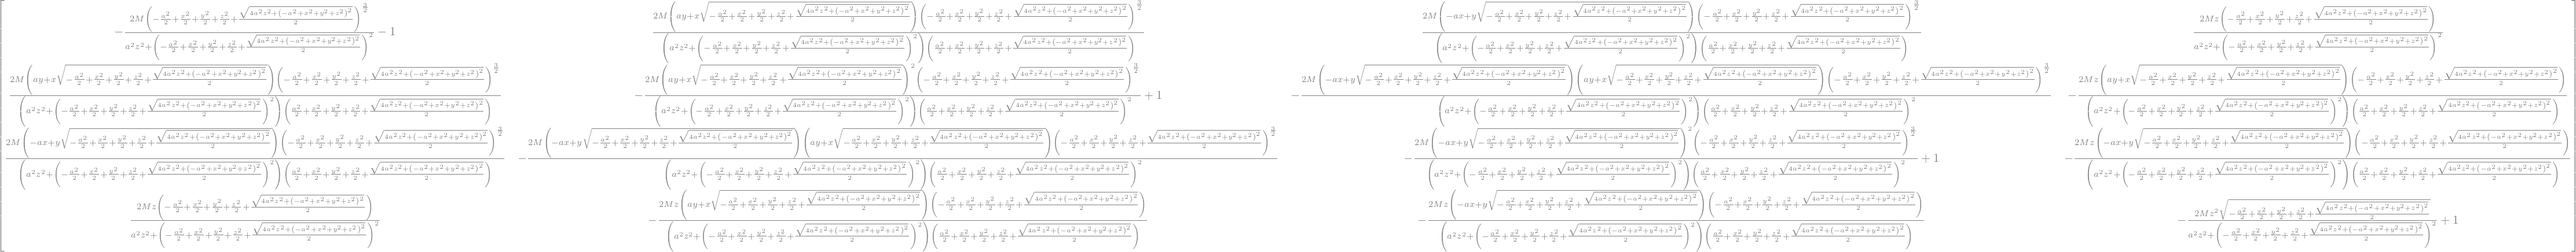

In [10]:
g_contra = eta_inv - 2*H*(ell_contra * ell_contra.T)
g_contra


### Numerical inverse check

Before attempting a fully symbolic identity matrix simplification, we first check the inverse numerically. This is a good example of the performance philosophy of this project: use symbolic algebra where it adds information, not merely because it is available.


In [11]:
g_cov_num = sp.lambdify((x, y, z, M, a), g_cov, modules='numpy', cse=True, docstring_limit=0)
g_contra_num = sp.lambdify((x, y, z, M, a), g_contra, modules='numpy', cse=True, docstring_limit=0)

import numpy as np

gc = np.asarray(g_cov_num(8.0, 1.5, 0.7, 1.0, 0.5), dtype=float)
gi = np.asarray(g_contra_num(8.0, 1.5, 0.7, 1.0, 0.5), dtype=float)

inverse_error = gc @ gi - np.eye(4)
print('max |g @ g_inv - I| =', np.max(np.abs(inverse_error)))
inverse_error


max |g @ g_inv - I| = 2.220446049250313e-16


array([[ 2.22044605e-16, -9.10947415e-18, -3.65157846e-18,
        -5.91044114e-19],
       [-4.55343153e-17, -2.22044605e-16,  1.75623994e-18,
         1.46409310e-18],
       [-6.64156592e-18,  1.60716214e-18, -1.11022302e-16,
         2.55422117e-19],
       [ 5.91044114e-19, -2.00535385e-18, -1.78258752e-19,
         0.00000000e+00]])

## 6. Schwarzschild limit: $a\rightarrow 0$

A critical validation test is that Kerr reduces to Schwarzschild when the spin parameter vanishes.

For $a=0$,

$$r\rightarrow\sqrt{x^2+y^2+z^2}$$

and

$$H\rightarrow\frac{M}{r}.$$


r^2 at a=0:


H at a=0:


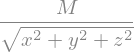

In [12]:
r2_a0 = sp.simplify(r2.subs(a, 0))
H_a0 = sp.simplify(H.subs(a, 0))

print('r^2 at a=0:')
display(r2_a0)

print('H at a=0:')
display(H_a0)


Because SymPy retains principal-value square roots, expressions may appear as $\sqrt{x^2+y^2+z^2}$ rather than a separate symbol $r$. That is expected.


## 7. Flat-spacetime limit: $M\rightarrow 0$

When $M=0$, $H=0$, so the metric must reduce exactly to Minkowski spacetime.


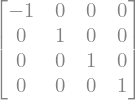

In [13]:
flat_check = g_cov.subs(M, 0)
flat_check


This should be exactly

$$\mathrm{diag}(-1,1,1,1).$$


## 8. Numerical performance benchmark

This is our first small benchmark. The goal is to confirm that after `lambdify`, repeated metric evaluations are ordinary fast numerical operations rather than symbolic substitutions.


In [14]:
import time

# Warm-up call
_ = g_cov_num(8.0, 1.5, 0.7, 1.0, 0.5)

n_eval = 10_000
start = time.perf_counter()

for _ in range(n_eval):
    g_cov_num(8.0, 1.5, 0.7, 1.0, 0.5)

elapsed = time.perf_counter() - start

print(f'{n_eval:,} metric evaluations: {elapsed:.6f} s')
print(f'average per evaluation: {1e6*elapsed/n_eval:.3f} microseconds')


10,000 metric evaluations: 0.028802 s
average per evaluation: 2.880 microseconds


## What comes next

The next notebook will derive the quantities needed for geodesic motion **without blindly simplifying all 64 Christoffel symbols**.

We will:

1. derive spatial derivatives of the metric,
2. exploit stationarity ($\partial_t g_{\mu\nu}=0$),
3. build the contracted geodesic acceleration
   $$A^\mu=-\Gamma^\mu_{\alpha\beta}u^\alpha u^\beta,$$
4. apply common-subexpression elimination jointly to the four $A^\mu$ components,
5. turn them into fast numerical functions,
6. benchmark the resulting RHS before writing any RK4 loop.

Only after that benchmark passes will we integrate trajectories.
